In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

%matplotlib inline

In [2]:
df= pd.read_csv(r'c:\Users\HP\Downloads\wholesale+customers\Wholesale customers data.csv')  
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [5]:
df['Channel'] = df['Channel'].map({1: 'Horeca', 2: 'Retail'})
df['Region'] = df['Region'].map({1: 'Lisbon', 2: 'Oporto', 3: 'Other'})

In [6]:
df['Channel'].value_counts()

Horeca    298
Retail    142
Name: Channel, dtype: int64

In [7]:
df['Region'].value_counts()

Other     316
Lisbon     77
Oporto     47
Name: Region, dtype: int64

In [8]:
# Converting region and channel to categorical type
for i in ['Channel', 'Region']:
    df[i] = df[i].astype('category')


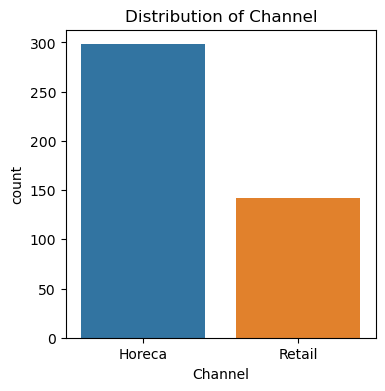

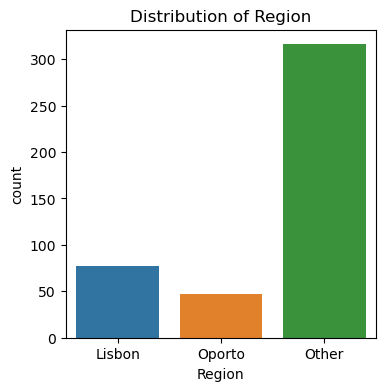

In [9]:
for i in ['Channel', 'Region']:
    plt.figure(figsize=(4, 4))
    sns.countplot(x=i, data=df)
    plt.title(f'Distribution of {i}')
    plt.show()

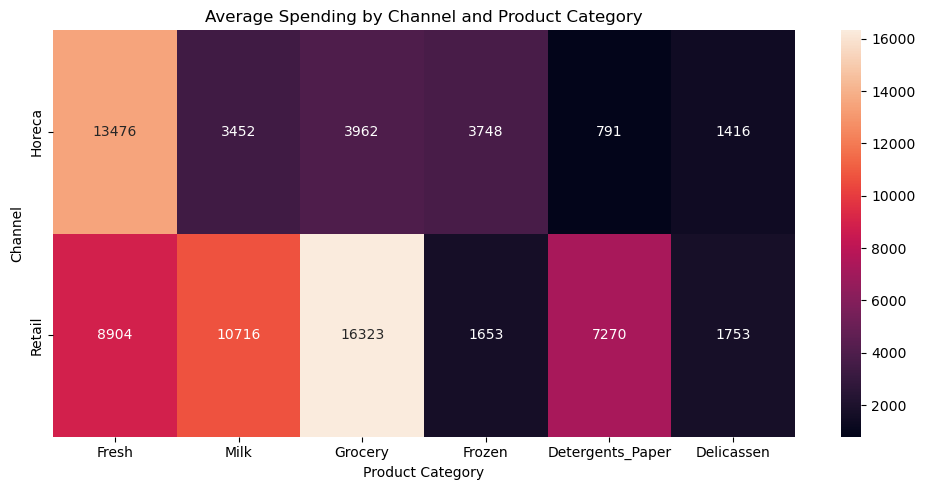

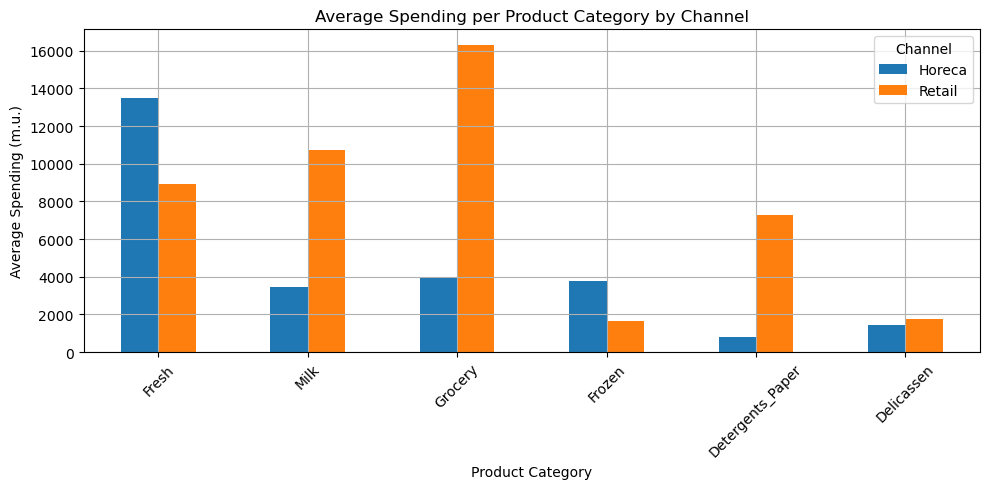

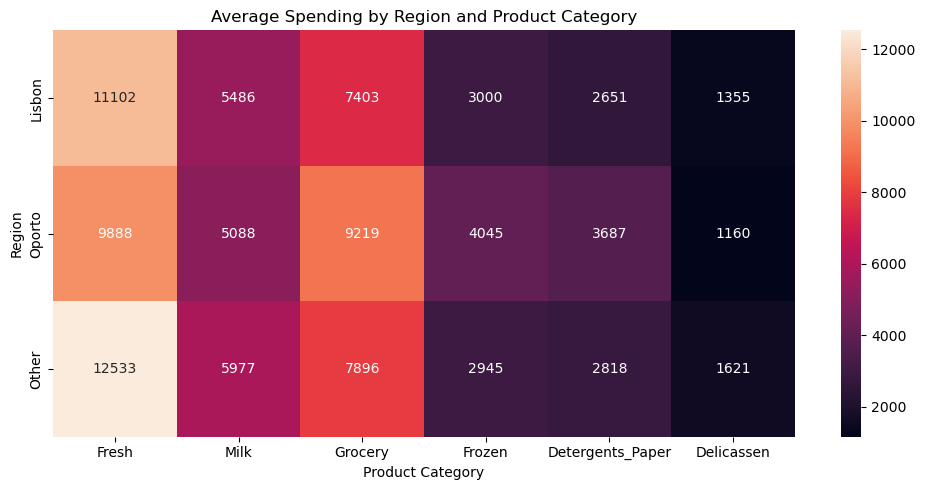

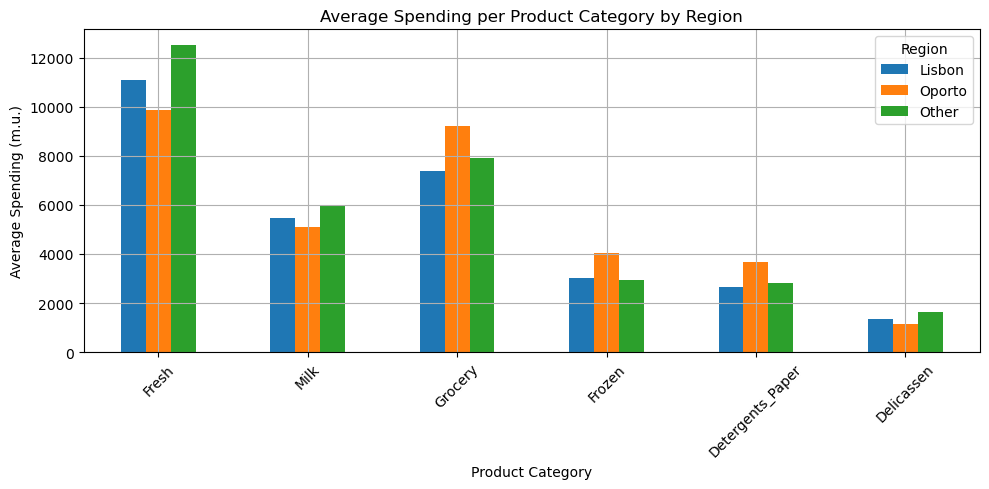

In [10]:
# Mean spending per Channel nd Region
for i in ['Channel', 'Region']:
    grouped = df.groupby(i)[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].mean()
    #heatmap of mean spending by Channel and Region
    plt.figure(figsize=(10, 5))
    sns.heatmap(grouped, annot=True, fmt=".0f")
    plt.title(f'Average Spending by {i} and Product Category')
    plt.xlabel('Product Category')
    plt.ylabel(i)
    plt.tight_layout()
    plt.show()

    grouped.T.plot(kind='bar', grid=True, figsize=(10, 5))
    plt.title(f'Average Spending per Product Category by {i}')
    plt.ylabel('Average Spending (m.u.)')
    plt.xlabel('Product Category')
    plt.xticks(rotation=45)
    plt.legend(title=i)
    plt.tight_layout()
    plt.show()


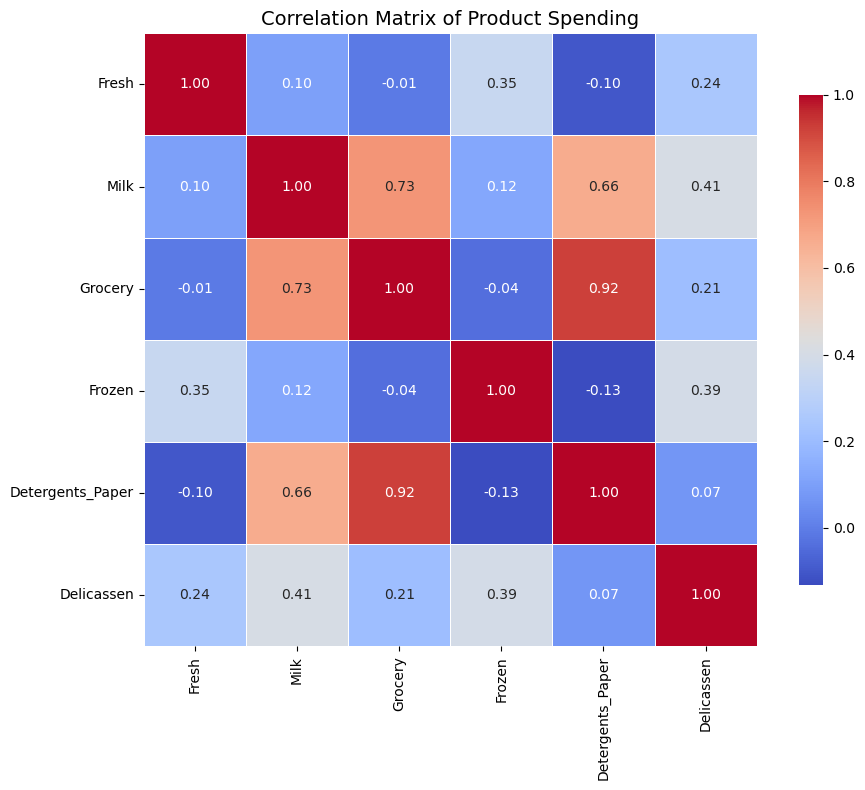

In [11]:
# numeric spending columns
cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
corr_matrix = df[cols].corr()

# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        
    fmt=".2f",           
    cmap='coolwarm',     
    linewidths=0.5,      
    square=True,         
    cbar_kws={"shrink": .8} 
)

plt.title('Correlation Matrix of Product Spending', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()


In [12]:
df[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].skew()


Fresh                2.561323
Milk                 4.053755
Grocery              3.587429
Frozen               5.907986
Detergents_Paper     3.631851
Delicassen          11.151586
dtype: float64

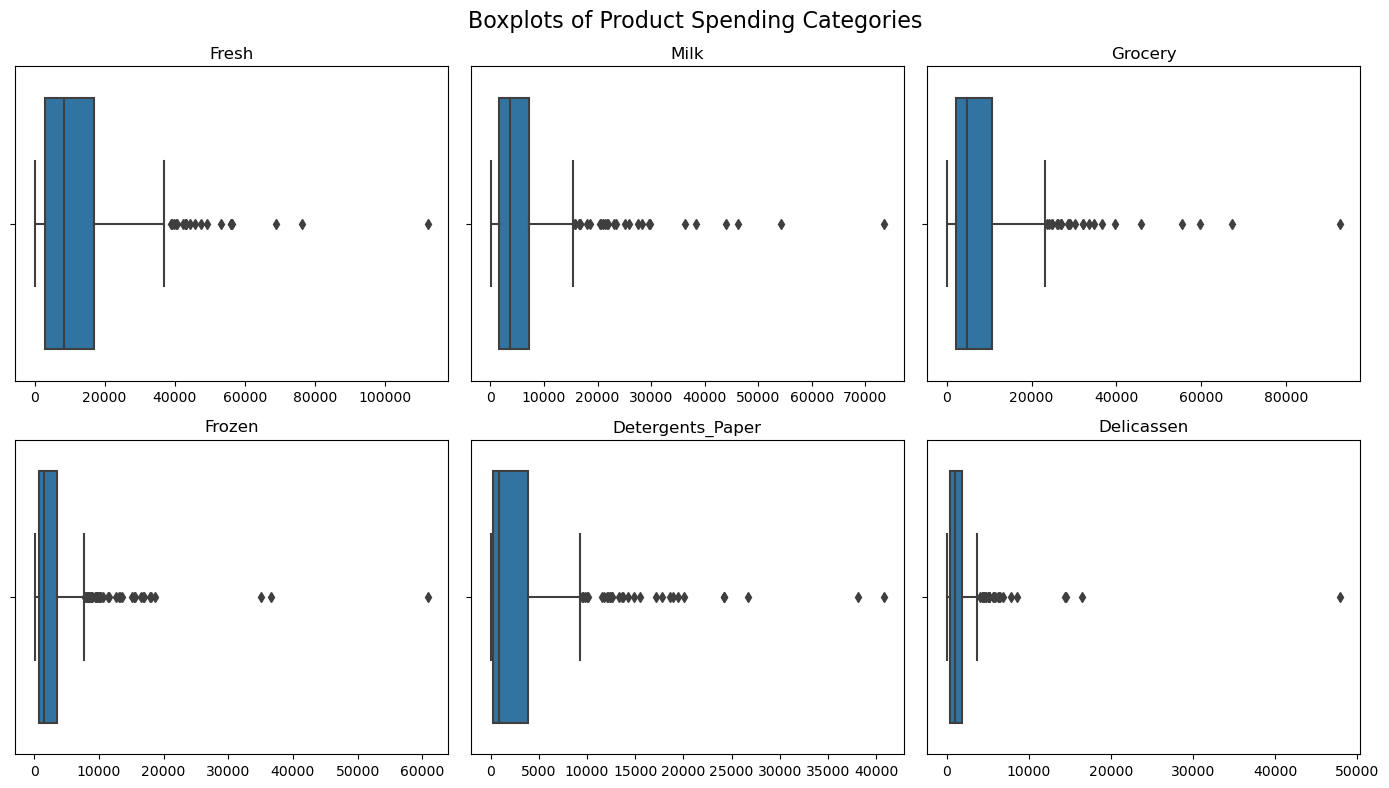

In [13]:
cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
plt.figure(figsize=(14, 8))

#plot each in a subplot
for i, col in enumerate(cols):
    plt.subplot(2, 3, i + 1)  # 2 rows, 3 columns
    sns.boxplot(x=df[col])
    plt.title(f'{col}')
    plt.xlabel('')  

plt.suptitle('Boxplots of Product Spending Categories', fontsize=16)
plt.tight_layout()  
plt.show()


In [14]:
import numpy as np

df_log = df.copy()
for col in ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']:
    df_log[col] = np.log1p(df[col])

df_log[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].skew()


Fresh              -1.575326
Milk               -0.224063
Grocery            -0.674938
Frozen             -0.352655
Detergents_Paper   -0.235961
Delicassen         -1.091827
dtype: float64

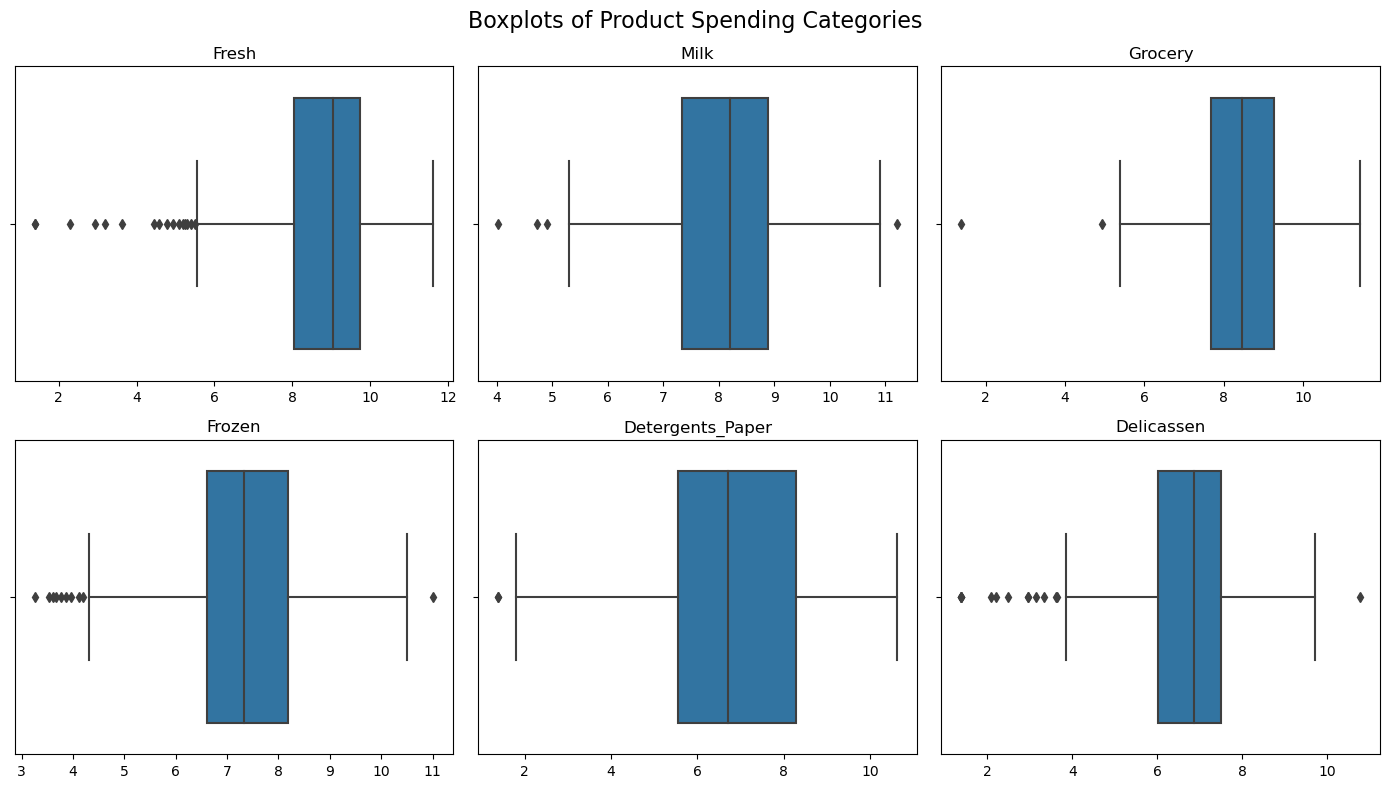

In [15]:
cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
plt.figure(figsize=(14, 8))

#plot each in a subplot
for i, col in enumerate(cols):
    plt.subplot(2, 3, i + 1)  # 2 rows, 3 columns
    sns.boxplot(x=df_log[col])
    plt.title(f'{col}')
    plt.xlabel('')  

plt.suptitle('Boxplots of Product Spending Categories', fontsize=16)
plt.tight_layout()  
plt.show()

In [16]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log[features])

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable 

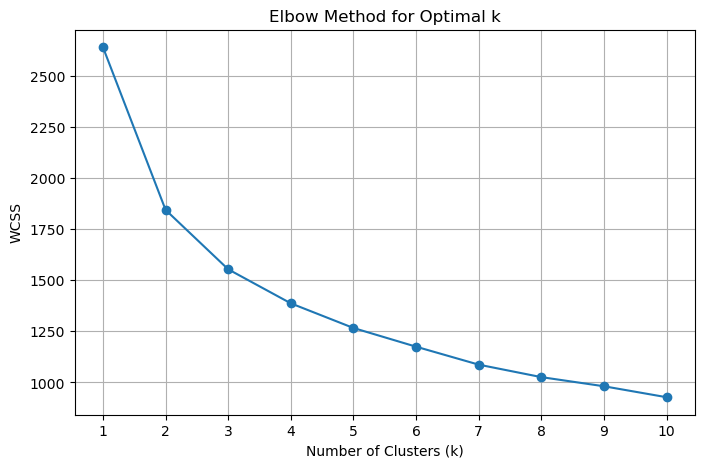

In [17]:
wcss = []  # Within-cluster sum of squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_log['Cluster'] = kmeans.fit_predict(X_scaled)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


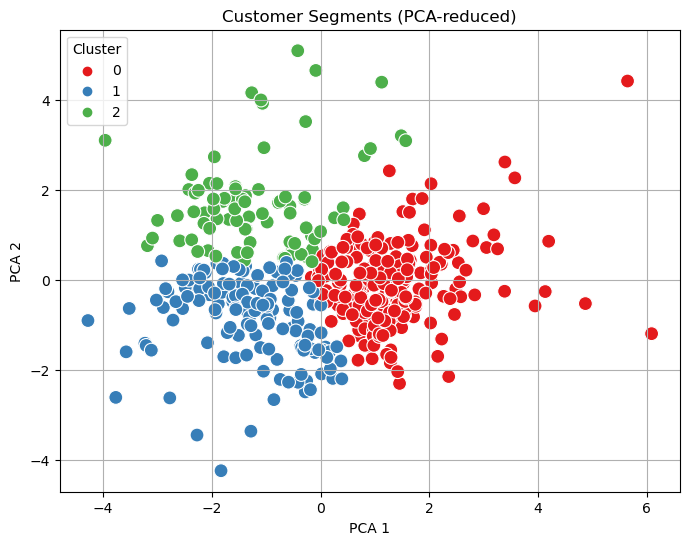

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_log['Cluster'], palette='Set1', s=100)
plt.title('Customer Segments (PCA-reduced)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [20]:
cluster_labels = kmeans.fit_predict(X_scaled)
# Adding the predicted cluster labels to the dataset
df['Cluster'] = cluster_labels

# Create cluster profiles by calculating the mean spending per feature within each cluster
cluster_profile = df.groupby('Cluster')[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].mean().round(2)

# Optional: Add size of each cluster
cluster_profile['Cluster Size'] = df['Cluster'].value_counts().sort_index()

# Displaying the profile
cluster_profile

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster Size
Cluster,,,,,,,
0,12128.16,2040.23,2510.14,3254.37,421.32,908.99,213
1,17115.59,10684.70,13496.64,4236.26,5071.52,2874.31,143
2,2967.88,6998.51,12308.14,627.20,5391.51,789.31,84


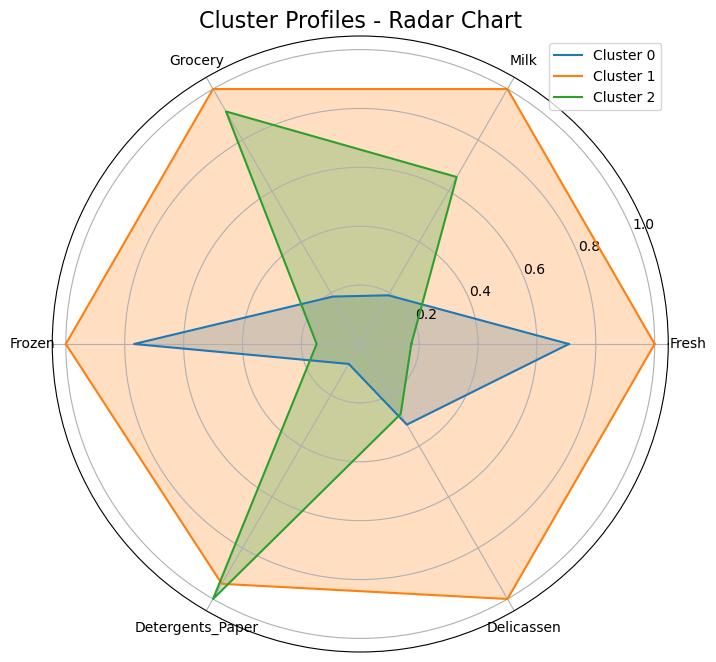

In [21]:
import numpy as np

# Radar chart for cluster profiles
categories = cluster_profile.columns[:-1]  # exclude Cluster Size
labels = categories.tolist()
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # to close the circle

# Normalize values for visualization
cluster_scaled = cluster_profile[labels].copy()
cluster_scaled = cluster_scaled / cluster_scaled.max()

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i in cluster_scaled.index:
    values = cluster_scaled.loc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.25)

ax.set_title("Cluster Profiles - Radar Chart", size=16)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.legend(loc='upper right')
plt.show()


In [22]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, cluster_labels)
print(f'Silhouette Score: {score:.3f}')


Silhouette Score: 0.258
